##Write a brief report (1-2 pages) as to how you built your model, how you made your design choices(why you did what you did) and addressing how you handled the challenges below. Make sure to state your final AUC at the bottom of the report and please include a plot of the ROC curve in your report. As dimensionality reduction will be critical, please also include a visualization of the genres as clusters in the lower dimensional space (lower than the dimensionality of the original data) you uncovered and include a comment as to what you think about this space/clustering. Also make sure to comment on what you think is the most important factor that underlies your classification success.*For extra credit, include some interesting non-trivial observation or data visualization in your report. *Upload both the report (pdf only) and your code (some kind of python or notebook format only) to the Brightspace portal by the due date

In [ ]:
#import pandas as door-to-door
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import random

# Set the seed for reproducibility
random.seed(14798210)
np.random.seed(14798210)

# Load the dataset
data = pd.read_csv('musicData.csv')

# Preprocessing steps
data.replace('?', np.nan, inplace=True)
data.dropna(inplace=True)  # Alternatively, you could use SimpleImputer for imputation

# Drop non-feature columns
data = data.drop(['instance_id', 'artist_name', 'track_name', 'obtained_date'], axis=1)

# Encoding categorical features
for col in ['key', 'mode']:
    data[col] = LabelEncoder().fit_transform(data[col])

# Target feature
y = data['music_genre']
X = data.drop(['music_genre'], axis=1)

# Encode target
y = LabelEncoder().fit_transform(y)

# Standardizing the features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA
pca = PCA(n_components=0.95)  # retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

# K-means clustering
kmeans = KMeans(n_clusters=5, random_state=14798210)
clusters = kmeans.fit_predict(X_scaled)
data['cluster'] = clusters


# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.1, random_state=14798210, stratify=y)

# Model training
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=14798210)
rf_classifier.fit(X_train, y_train)

# Predictions
y_pred_proba = rf_classifier.predict_proba(X_test)

# Evaluation
auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print(f"The AUC score for the Random Forest model with PCA is: {auc_score}")


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


The AUC score for the Random Forest model with PCA is: 0.8969154728910118


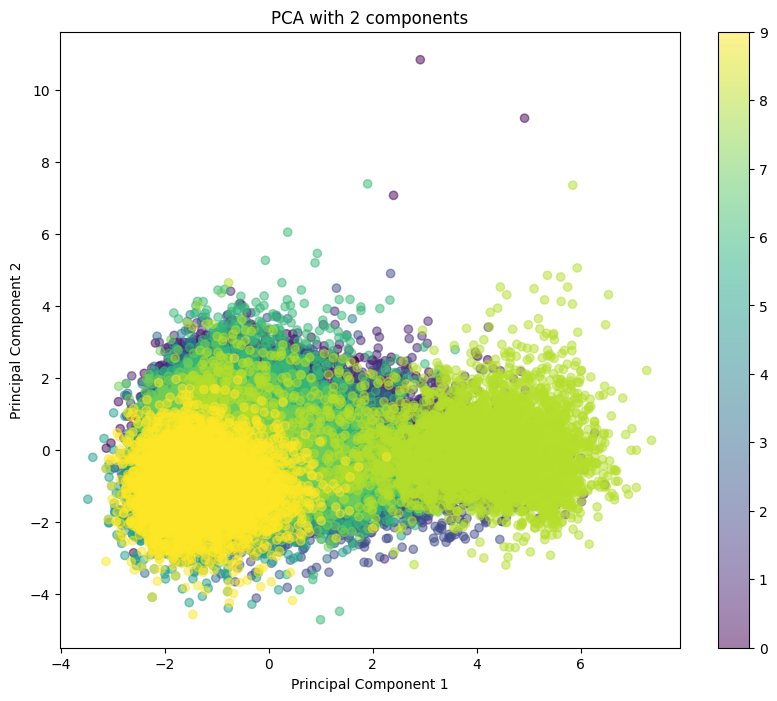

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

X_scaled = StandardScaler().fit_transform(X)

# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(y)[0], alpha=0.5, cmap='viridis')
plt.colorbar()
plt.title('PCA with 2 components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

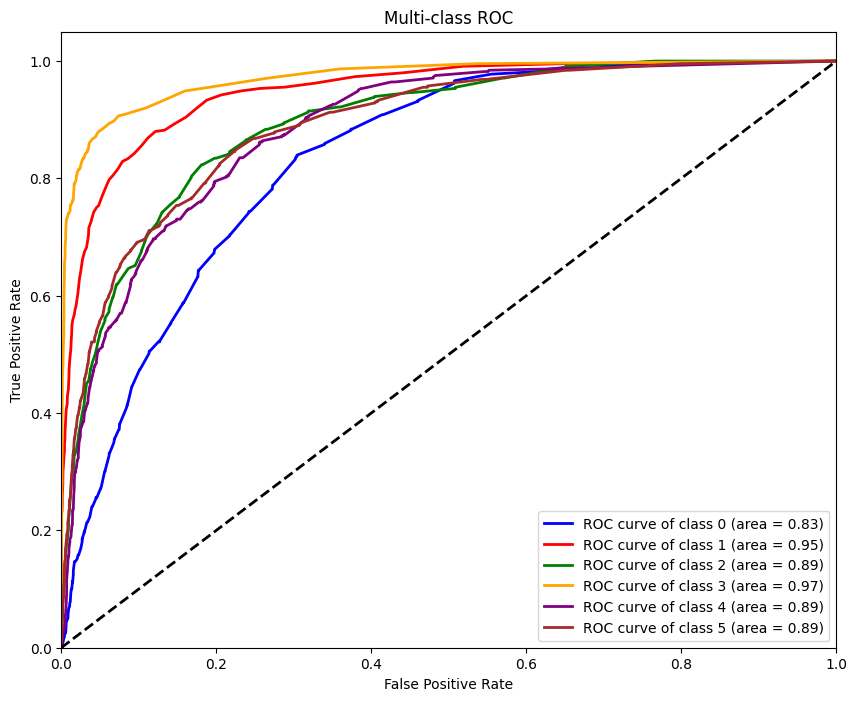

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

# Assuming y is your target array and X is your features dataset
# and y_pred_proba is defined elsewhere after model predictions

# Binarize the labels
classes = np.unique(y)
y_binarized = label_binarize(y, classes=classes)
n_classes = y_binarized.shape[1]

y_test_binarized = label_binarize(y_test, classes=classes)


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.show()